Group Members: Andrew Mankin, Ryan Safa

So there is no reduced feature set

We are also just going to do a simple cnn

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.image as img
import os
import cv2
from sklearn.model_selection import train_test_split
tf.keras.backend.clear_session()

In [6]:
df = pd.read_csv("./dataset/labels.csv")

In [7]:
df

,image,photometric,label
0,./dataset/images/sub-S03224_ses-E08049_run-1_b...,MONOCHROME1,1
1,./dataset/images/sub-S28417_ses-E60904_run-2_b...,MONOCHROME2,0
2,./dataset/images/sub-S03071_ses-E06165_run-1_b...,MONOCHROME2,1
3,./dataset/images/sub-S03113_ses-E07104_run-1_b...,MONOCHROME1,1
4,./dataset/images/sub-S03119_ses-E06213_run-1_b...,MONOCHROME2,1
...,...,...,...
1252,./dataset/images/sub-S08032_ses-E14275_run-1_b...,MONOCHROME2,0
1253,./dataset/images/sub-S03106_ses-E06431_acq-2_r...,MONOCHROME2,1
1254,./dataset/images/sub-S03056_ses-E07055_run-1_b...,MONOCHROME2,1
1255,./dataset/images/sub-S05731_ses-E10513_run-1_b...,MONOCHROME2,0


preprocess all the image paths to matplotlib images

In [8]:
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Bad image:", path)
        return None

    img = cv2.resize(img, (64, 64))
    img = img.astype("float32") / 255.0
    return img

In [9]:
images = []
labels = []

for path, label in zip(df["image"], df["label"]):
    img = load_image(path)
    if img is None:
        continue
    images.append(img)
    labels.append(label)

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.float32)

libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


In [11]:
X = np.expand_dims(X, axis=-1)

In [12]:
print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("X min/max:", X.min(), X.max())

print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("labels:", set(y))

X shape: (1257, 64, 64, 1)
X dtype: float32
X min/max: 0.0 1.0
y shape: (1257,)
y dtype: float32
labels: {np.float32(0.0), np.float32(1.0)}


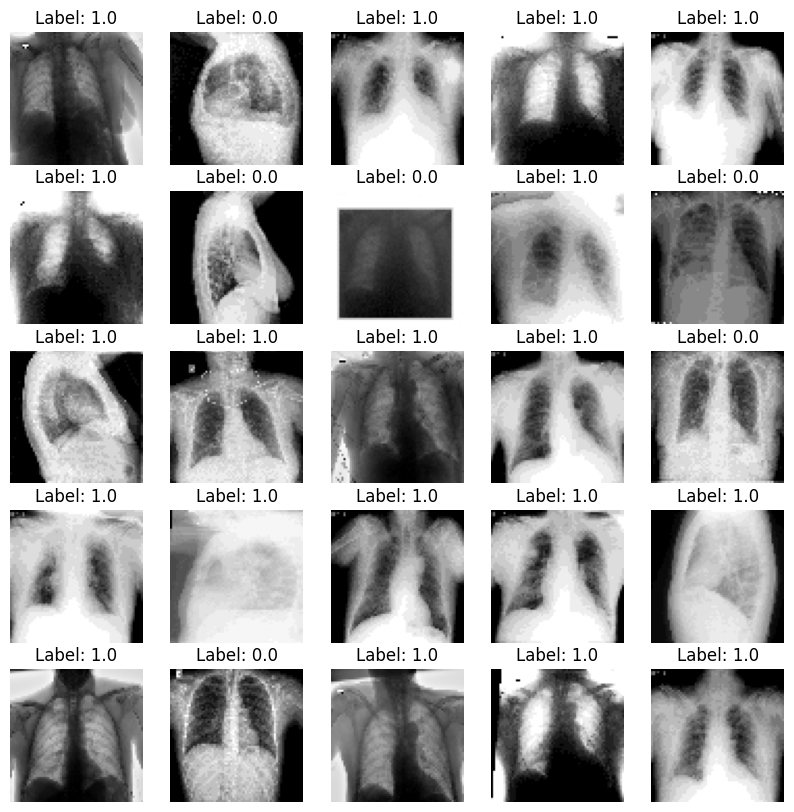

In [10]:
# verifiy the data
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

Split the data into train and test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
print(X_train.shape)
print(X_test.shape)


(1005, 64, 64, 1)
(252, 64, 64, 1)


In [47]:
model = models.Sequential([
    tf.keras.Input(shape=(64, 64, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

In [48]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,713 (1.48 MB)

 Trainable params: 387,713 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [51]:
history = model.fit(
    X_train,
    y_train.astype("float32"),
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7741 - loss: 0.4665 - val_accuracy: 0.7421 - val_loss: 0.4614
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.7841 - loss: 0.4572 - val_accuracy: 0.7579 - val_loss: 0.4495
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.7781 - loss: 0.4563 - val_accuracy: 0.7421 - val_loss: 0.5078
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7950 - loss: 0.4343 - val_accuracy: 0.7619 - val_loss: 0.4744
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7851 - loss: 0.4198 - val_accuracy: 0.7540 - val_loss: 0.4646
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8080 - loss: 0.4199 - val_accuracy: 0.7857 - val_loss: 0.4578
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7930 - loss: 0.4336 - val_accuracy: 0.7540 - val_loss: 0.4533
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8040 - loss: 0.4124 - val_accuracy: 0.7857 - v

8/8 - 0s - 14ms/step - accuracy: 0.7579 - loss: 0.4465


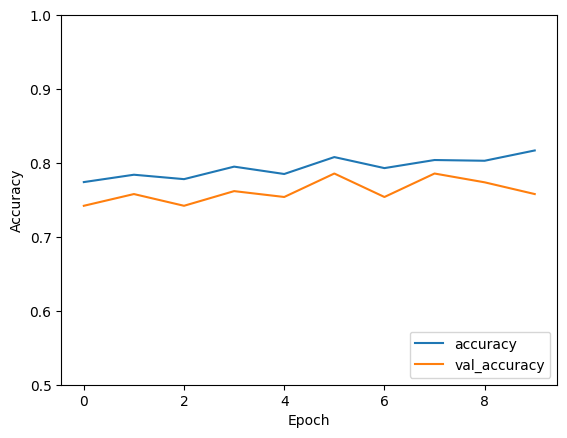

In [52]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)